In [101]:
import torch
import pandas as pd
import networkx as nx
from torch_geometric.data import Data
from torch_geometric.utils import from_networkx

nodes_df = pd.read_csv("./pre_processing_output/multi_label_nodes.csv")  # Dataset con nodi (proteine)
edges_df = pd.read_csv("./pre_processing_output/edges.csv")  # Dataset con interazioni proteina-proteina

nodes_tensored_df = nodes_df.copy()

nodes_tensored_df['GO_embeddings'] = nodes_tensored_df['GO_embeddings'].apply(lambda x: torch.tensor(eval(x), dtype=torch.float))
nodes_tensored_df['label'] = nodes_tensored_df['label'].apply(lambda x: torch.tensor(eval(x), dtype=torch.int))

G = nx.Graph()
for _, row in nodes_tensored_df.iterrows():
    G.add_node(row['num_id'], x=row['GO_embeddings'], y=torch.tensor(row['label'], dtype=torch.int64))

edges = torch.tensor(edges_df[['num_id_1', 'num_id_2']].values.T, dtype=torch.long)

data = Data(
    x=torch.stack([G.nodes[n]['x'] for n in G.nodes]),  # Feature matrix
    edge_index=edges,  # Edge list
    y=torch.stack([G.nodes[n]['y'] for n in G.nodes])  # Multilabel target
)

print(data)


Data(x=[179, 200], edge_index=[2, 666], y=[179, 2])


/tmp/ipykernel_68970/1628605884.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  G.add_node(row['num_id'], x=row['GO_embeddings'], y=torch.tensor(row['label'], dtype=torch.int64))


In [102]:
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random

def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

set_seed()

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, 2)  # Output con 2 classi (AD, PD)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return torch.sigmoid(x)  # Sigmoid per output multilabel

# Definizione training

from torch.optim import Adam

from sklearn.model_selection import train_test_split
import torch

# Convertiamo y in una classe singola per stratificare (concatenazione delle due classi in stringa)
y_single_class = [''.join(map(str, label.tolist())) for label in data.y]  # Es. ['10', '01', '11', ...]

# **1️⃣ Stratified Split per ottenere Train e (Validation+Test)**
x_train, x_temp, y_train, y_temp = train_test_split(
    data.x, data.y, test_size=0.3, stratify=y_single_class, random_state=42  # Mantiene proporzioni tra le classi
)

# **2️⃣ Split ulteriore tra Validation e Test (50%-50%)**
y_temp_single_class = [''.join(map(str, label.tolist())) for label in y_temp]  # Ricalcoliamo la classe per stratificare
x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.5, stratify=y_temp_single_class, random_state=42
)

# **3️⃣ Convertiamo tutto in Tensori PyTorch**
x_train, y_train = torch.tensor(x_train, dtype=torch.float), torch.tensor(y_train, dtype=torch.float)
x_val, y_val = torch.tensor(x_val, dtype=torch.float), torch.tensor(y_val, dtype=torch.float)
x_test, y_test = torch.tensor(x_test, dtype=torch.float), torch.tensor(y_test, dtype=torch.float)

# **4️⃣ Controlliamo il bilanciamento**
from collections import Counter
print("Distribuzione classi nel Training Set:", Counter(y_single_class))
print("Distribuzione classi nel Validation Set:", Counter(y_temp_single_class))


# TODO: metti in un file di config i parametri
model = MLP(input_dim=data.x.shape[1], hidden_dim=64)
optimizer = Adam(model.parameters(), lr=0.0001, weight_decay=5e-4)
criterion = nn.BCEWithLogitsLoss()  # BCE per multilabel classification

def train(model, optimizer, criterion, x_train, y_train):
    """
    :model: modello da allenare
    :optimizer: ottimizzatore del modello
    :criterion: loss function
    :x_train: training samples (test partition)
    :y_train: training labels (test partition)
    """
    model.train()
    optimizer.zero_grad()

    # Forward pass su Training Set
    out_train = model(x_train)
    loss_train = criterion(out_train, y_train)

    # Backpropagation
    loss_train.backward()
    optimizer.step()
    return loss_train.item()

# Metriche di valutazione

from sklearn.metrics import roc_auc_score, f1_score

def test():
    model.eval()
    with torch.no_grad():
        out = model(x_test)  # Predizioni del modello
        pred = (out > 0.5).int()  # Threshold su 0.5 per multilabel
        y_true = y_test.numpy()
        y_pred = pred.numpy()

        # AUC-ROC per ciascuna classe
        auc_ad = roc_auc_score(y_true[:, 0], y_pred[:, 0])
        auc_pd = roc_auc_score(y_true[:, 1], y_pred[:, 1])
        f1 = f1_score(y_true, y_pred, average="macro")  # Macro-F1 per multilabel

        print(f"AUC-AD: {auc_ad:.4f}, AUC-PD: {auc_pd:.4f}, F1-Score: {f1:.4f}")

Distribuzione classi nel Training Set: Counter({'10': 92, '01': 75, '11': 12})
Distribuzione classi nel Validation Set: Counter({'10': 28, '01': 23, '11': 3})


/tmp/ipykernel_68970/2551681748.py:49: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_train, y_train = torch.tensor(x_train, dtype=torch.float), torch.tensor(y_train, dtype=torch.float)
/tmp/ipykernel_68970/2551681748.py:50: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_val, y_val = torch.tensor(x_val, dtype=torch.float), torch.tensor(y_val, dtype=torch.float)
/tmp/ipykernel_68970/2551681748.py:51: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_test, y_test = torch.tensor(x_test, dtype=torch.float), torch.tensor(y_test, dtype=torch.fl

Training Progress:   3%|▎         | 30/1000 [00:00<00:03, 292.17epoch/s, Train Loss=0.6830, Val Loss=0.6874]

tensor([[ 2.6145e+00,  1.0378e+00,  1.1957e+00,  ..., -2.1661e+00,
          2.1453e+00, -2.0553e+00],
        [ 5.8029e+00, -1.7467e+00,  6.0493e+00,  ..., -5.8144e+00,
          3.5088e+00, -2.5243e+00],
        [ 2.0826e+00,  2.6781e-01,  2.7493e-01,  ..., -1.5750e+00,
          1.4587e+00, -2.8818e-01],
        ...,
        [ 7.0195e+00,  5.0985e-03,  4.0607e+00,  ..., -8.4972e-01,
          5.8086e+00, -4.3916e+00],
        [ 9.8470e-01,  1.3876e+00, -8.7689e-02,  ..., -2.9520e+00,
          1.1099e+00, -1.3800e+00],
        [ 4.7988e+00, -1.7113e+00,  2.4282e+00,  ..., -1.5168e+00,
          1.5468e+00, -2.7720e+00]])
tensor([[0., 1.],
        [1., 0.],
        [0., 1.],
        [0., 1.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [0., 1.],
        [0., 1.],
        [0., 1.],
        [0., 1.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [0., 1.],
        [0., 1.],
        [0., 1.],
        [1., 0.],
        [1., 0.],
        

Training Progress: 100%|██████████| 1000/1000 [00:02<00:00, 382.06epoch/s, Train Loss=0.4972, Val Loss=0.5968]


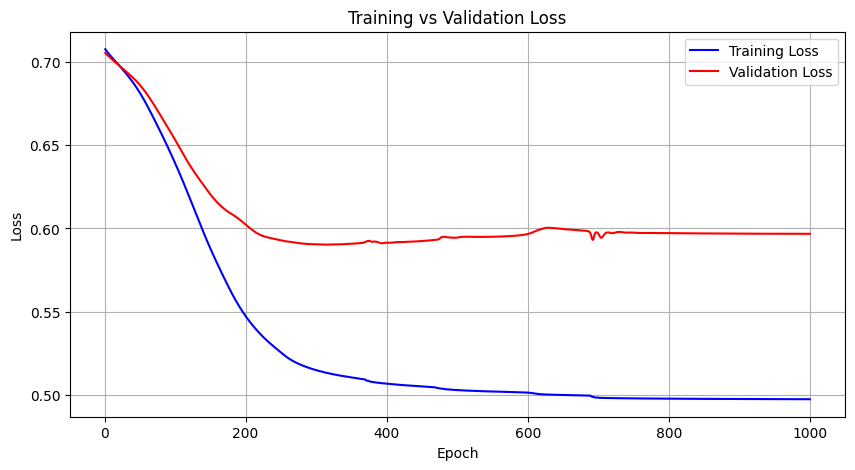

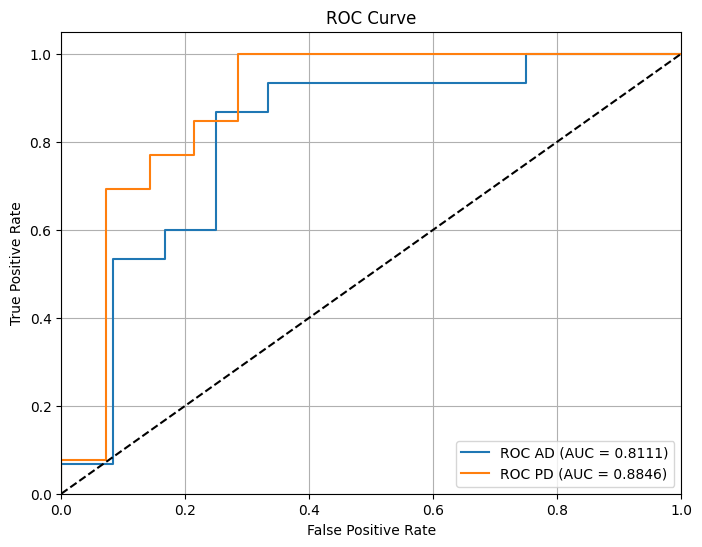

AUC-AD: 0.7583, AUC-PD: 0.8159, F1-Score: 0.8192


In [103]:
import matplotlib.pyplot as plt
from tqdm import tqdm

num_epochs = 1000
train_loss_values = []
val_loss_values = []

progress_bar = tqdm(range(num_epochs), desc="Training Progress", unit="epoch", dynamic_ncols=True)

print(x_train)
print(y_train)
for epoch in progress_bar:
    loss_values_train = train(model, optimizer, criterion, x_train, y_train)

    # Evaluazione sul validation set
    model.eval()
    with torch.no_grad():
        out_val = model(x_val)
        loss_values_eval = criterion(out_val, y_val)
    
    # Salviamo le loss
    train_loss_values.append(loss_values_train)
    val_loss_values.append(loss_values_eval.item())

    # Mostriamo la loss in tempo reale
    progress_bar.set_postfix({"Train Loss": f"{loss_values_train:.4f}", "Val Loss": f"{loss_values_eval:.4f}"})

# Plotting delle loss
plt.figure(figsize=(10,5))
plt.plot(range(1, num_epochs+1), train_loss_values, label="Training Loss", color='b')
plt.plot(range(1, num_epochs+1), val_loss_values, label="Validation Loss", color='r')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_roc_curve(y_true, y_pred, class_names=["AD", "PD"]):
    plt.figure(figsize=(8,6))
    
    for i in range(2):  # Due classi (AD e PD)
        fpr, tpr, _ = roc_curve(y_true[:, i], y_pred[:, i])
        roc_auc = auc(fpr, tpr)  # Calcola l'AUC
        plt.plot(fpr, tpr, label=f'ROC {class_names[i]} (AUC = {roc_auc:.4f})')

    plt.plot([0, 1], [0, 1], 'k--')  # Linea diagonale random
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

with torch.no_grad():
    out_test = model(x_test)  # Output del modello sul test set
    y_pred = out_test.numpy()  # Convertiamo in array numpy
    y_true = y_test.numpy()  # Ground truth

    plot_roc_curve(y_true, y_pred)

test()


In [104]:
def test_single_node(model, node_id, nodes_df, trained_data):
    """
    Testa un nodo specifico identificato dal suo ID nel dataset originale.
    
    Parameters:
        model: il modello allenato (MLP o GCN)
        node_id: ID del nodo da testare (deve essere presente in nodes_df)
        nodes_df: DataFrame contenente le informazioni sui nodi (STRING_id, num_id, GO_embeddings, label)
        trained_data: Il dataset di PyTorch Geometric (data.x e data.y) per recuperare le feature
    """
    model.eval()  # Settiamo il modello in modalità valutazione

    if node_id not in nodes_df["STRING_id"].values:
        print(f"Nodo {node_id} non trovato nel dataset!")
        return

    node_row = nodes_df[nodes_df["STRING_id"] == node_id].iloc[0]
    num_id = node_row["num_id"]  # Indice numerico del nodo
    true_label = torch.tensor(eval(node_row["label"]), dtype=torch.float)  # Etichetta vera

    sample_input = trained_data.x[num_id].unsqueeze(0)

    with torch.no_grad():
        prediction = model(sample_input)  # Predizione del modello
        predicted_probabilities = prediction.numpy().flatten()  # Convertiamo in array

    print(f"Test Nodo {node_id} (num_id={num_id})")
    print(f"True Label:\t\tAD={true_label[0].item()}, PD={true_label[1].item()}")
    predicted_class = (predicted_probabilities > 0.5).astype(int)
    print(f"Predicted Class:\t AD={predicted_class[0]}, PD={predicted_class[1]}")
    print(f"Predicted Probabilities:\t AD={predicted_probabilities[0]:.4f}, PD={predicted_probabilities[1]:.4f}")

common_nodes = nodes_df[nodes_df["label"] == '(1, 1)']  # Supponiamo che 2 sia il valore per i nodi in comune    
common_node_ids = common_nodes["STRING_id"].tolist()
for id in common_node_ids:
    test_single_node(model, id, nodes_df, data)


Test Nodo 9606.ENSP00000377296 (num_id=158)
True Label:		AD=1.0, PD=1.0
Predicted Class:	 AD=0, PD=1
Predicted Probabilities:	 AD=0.0000, PD=1.0000
Test Nodo 9606.ENSP00000400906 (num_id=165)
True Label:		AD=1.0, PD=1.0
Predicted Class:	 AD=0, PD=1
Predicted Probabilities:	 AD=0.0048, PD=0.9996
Test Nodo 9606.ENSP00000354687 (num_id=138)
True Label:		AD=1.0, PD=1.0
Predicted Class:	 AD=0, PD=1
Predicted Probabilities:	 AD=0.0000, PD=1.0000
Test Nodo 9606.ENSP00000374455 (num_id=19)
True Label:		AD=1.0, PD=1.0
Predicted Class:	 AD=1, PD=0
Predicted Probabilities:	 AD=1.0000, PD=0.0004
Test Nodo 9606.ENSP00000264710 (num_id=17)
True Label:		AD=1.0, PD=1.0
Predicted Class:	 AD=0, PD=1
Predicted Probabilities:	 AD=0.0000, PD=1.0000
Test Nodo 9606.ENSP00000419782 (num_id=16)
True Label:		AD=1.0, PD=1.0
Predicted Class:	 AD=0, PD=1
Predicted Probabilities:	 AD=0.0000, PD=1.0000
Test Nodo 9606.ENSP00000366047 (num_id=139)
True Label:		AD=1.0, PD=1.0
Predicted Class:	 AD=0, PD=1
Predicted Prob

Data(x=[167, 200], edge_index=[2, 542], y=[167])
📊 Train: 116 nodi, Label distribution: tensor([64, 52])
📊 Validation: 25 nodi, Label distribution: tensor([14, 11])
📊 Test: 26 nodi, Label distribution: tensor([14, 12])


Training Progress: 100%|██████████| 25/25 [00:00<00:00, 332.64epoch/s, Train Loss=0.1953, Val Loss=0.1953]


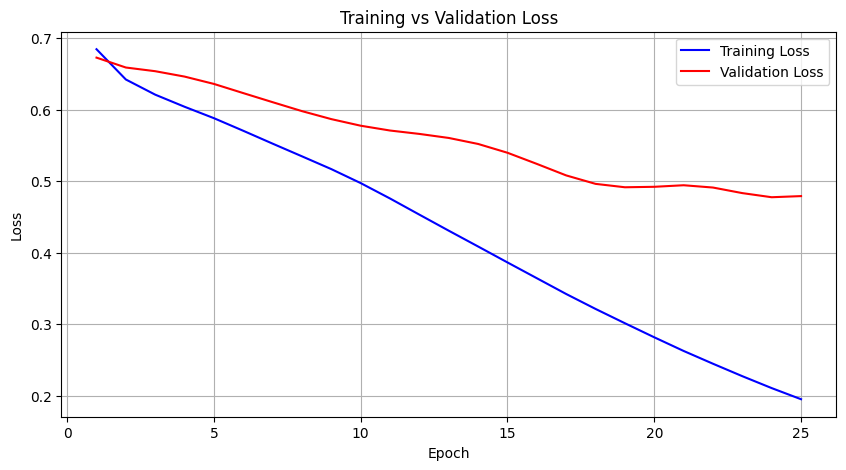

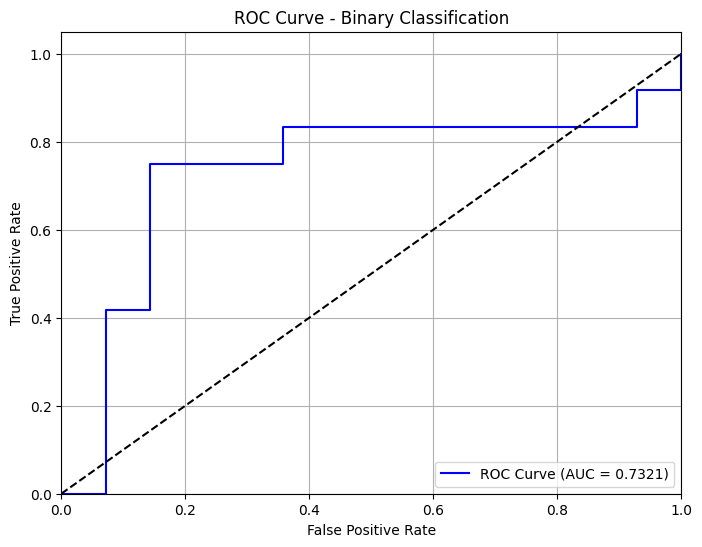

0.7321428571428571

Test Proteina 9606.ENSP00000377296 (num_id=158)
True Label: 2 (0 = AD, 1 = PD)
Predicted Logit: 1.1963
Confidence: 0.7679
Predicted Class: 1 (0 = AD, 1 = PD)


Test Proteina 9606.ENSP00000400906 (num_id=165)
True Label: 2 (0 = AD, 1 = PD)
Predicted Logit: -0.3772
Confidence: 0.4068
Predicted Class: 0 (0 = AD, 1 = PD)


Test Proteina 9606.ENSP00000354687 (num_id=138)
True Label: 2 (0 = AD, 1 = PD)
Predicted Logit: 2.0654
Confidence: 0.8875
Predicted Class: 1 (0 = AD, 1 = PD)


Test Proteina 9606.ENSP00000374455 (num_id=19)
True Label: 2 (0 = AD, 1 = PD)
Predicted Logit: -1.4237
Confidence: 0.1941
Predicted Class: 0 (0 = AD, 1 = PD)


Test Proteina 9606.ENSP00000264710 (num_id=17)
True Label: 2 (0 = AD, 1 = PD)
Predicted Logit: -0.9387
Confidence: 0.2812
Predicted Class: 0 (0 = AD, 1 = PD)


Test Proteina 9606.ENSP00000419782 (num_id=16)
True Label: 2 (0 = AD, 1 = PD)
Predicted Logit: -3.1097
Confidence: 0.0427
Predicted Class: 0 (0 = AD, 1 = PD)


Test Proteina 9606.

In [105]:
# Da questo punto lavoro al modello MLP escludendo dal dataset le proteine in comune e poi valutando le prestazioni del modello sia sul
#   dataset di test che sul dataset delle proteine in comune.

# 1. Divisione del dataset tra proteine specifiche ed in comune

nodes_df = pd.read_csv('./pre_processing_output/classification_nodes.csv')
edges_df = pd.read_csv('./pre_processing_output/edges.csv')

common_protein_ids = set(nodes_df[nodes_df['label'] == 2]['num_id'].to_list())

nodes_filtered_df = nodes_df[~(nodes_df['label'] == 2)]
edges_filtered_df = edges_df[~edges_df[['num_id_1', 'num_id_2']].isin(common_protein_ids).any(axis=1)]

nodes_tensored_df = nodes_filtered_df.copy()

nodes_tensored_df['GO_embeddings'] = nodes_tensored_df['GO_embeddings'].apply(lambda x: torch.tensor(eval(x), dtype=torch.float))

G = nx.Graph()
for _, row in nodes_tensored_df.iterrows():
    G.add_node(row['num_id'], x=row['GO_embeddings'], y=torch.tensor(row['label'], dtype=torch.int64))

edges = torch.tensor(edges_filtered_df[['num_id_1', 'num_id_2']].values.T, dtype=torch.long)

data = Data(
    x=torch.stack([G.nodes[n]['x'] for n in G.nodes]),  # Feature matrix
    edge_index=edges,  # Edge list
    y=torch.stack([G.nodes[n]['y'] for n in G.nodes])  # target
)

print(data)

# 2. Divisione del dataset di proteine specifiche in train/test/eval

from sklearn.model_selection import train_test_split
import torch

# **1️⃣ Creiamo maschere vuote per il train, validation e test**
train_mask = torch.zeros(len(data.y), dtype=torch.bool)  
val_mask = torch.zeros(len(data.y), dtype=torch.bool)  
test_mask = torch.zeros(len(data.y), dtype=torch.bool)  

# **2️⃣ Stratified Split per ottenere Train+Val e Test (15% test)**
train_val_idx, test_idx, y_train_val, y_test = train_test_split(
    torch.arange(len(data.y)), data.y.numpy(), test_size=0.15, stratify=data.y.numpy(), random_state=42
)

# **3️⃣ Stratified Split per ottenere Train (70%) e Validation (15%)**
train_idx, val_idx, y_train, y_val = train_test_split(
    train_val_idx, y_train_val, test_size=0.15/0.85, stratify=y_train_val, random_state=42
)

# **4️⃣ Assegniamo i nodi alle maschere**
train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

# **5️⃣ Controlliamo il bilanciamento**
print(f"📊 Train: {train_mask.sum().item()} nodi, Label distribution: {torch.bincount(data.y[train_mask].int())}")
print(f"📊 Validation: {val_mask.sum().item()} nodi, Label distribution: {torch.bincount(data.y[val_mask].int())}")
print(f"📊 Test: {test_mask.sum().item()} nodi, Label distribution: {torch.bincount(data.y[test_mask].int())}")

x_train, y_train = data.x[train_mask], data.y[train_mask]
x_val, y_val = data.x[val_mask], data.y[val_mask]
x_test, y_test = data.x[test_mask], data.y[test_mask]


# 3. Definizione ed addestramento del modello

import torch.optim as optim

class MLP_classification(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(MLP_classification, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x.squeeze()

model2 = MLP_classification(input_dim=data.x.shape[1], hidden_dim=64)
optimizer = optim.Adam(model2.parameters(), lr=0.001, weight_decay=5e-4)
classification_criteria = nn.BCEWithLogitsLoss()

import matplotlib.pyplot as plt
from tqdm import tqdm

num_epochs = 25
train_loss_values = []
val_loss_values = []

progress_bar = tqdm(range(num_epochs), desc="Training Progress", unit="epoch", dynamic_ncols=True)

for epoch in progress_bar:
    # loss_values_train = train(model2, optimizer, classification_criteria, x_train, y_train)

    model2.train()
    optimizer.zero_grad()

    # **Forward pass su Training Set**
    out_train = model2(data.x[train_mask]).squeeze()
    loss_train = classification_criteria(out_train, y_train.float())

    # **Backpropagation**
    loss_train.backward()
    optimizer.step()

    # Evaluazione sul validation set
    model2.eval()
    with torch.no_grad():
        out_val = model2(x_val)
        loss_values_eval = classification_criteria(out_val, y_val.float())
    
    # Salviamo le loss
    train_loss_values.append(loss_train.item())
    val_loss_values.append(loss_values_eval.item())

    # Mostriamo la loss in tempo reale
    progress_bar.set_postfix({"Train Loss": f"{loss_train.item():.4f}", "Val Loss": f"{loss_train.item():.4f}"})

# Plotting delle loss
plt.figure(figsize=(10,5))
plt.plot(range(1, num_epochs+1), train_loss_values, label="Training Loss", color='b')
plt.plot(range(1, num_epochs+1), val_loss_values, label="Validation Loss", color='r')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

with torch.no_grad():
    out_test = model2(x_test)  # Output del modello sul test set
    y_pred = out_test.numpy()  # Convertiamo in array numpy
    y_true = y_test.numpy()  # Ground truth

    plt.figure(figsize=(8,6))

    # Calcolo della curva ROC
    fpr, tpr, _ = roc_curve(y_true, y_pred)  # Ora usa solo array 1D
    roc_auc = auc(fpr, tpr)

    # Plot della ROC curve
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})', color='b')
    plt.plot([0, 1], [0, 1], 'k--')  # Linea diagonale random
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - Binary Classification')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    auc_roc = roc_auc_score(y_true, y_pred)  # ROC-AUC
    #f1 = f1_score(y_true, y_pred)  # F1-Score

    print(auc_roc)

# 4. Risultati

for id in nodes_df[nodes_df['num_id'].isin(common_protein_ids)]['STRING_id'].tolist():
    model2.eval()  # Settiamo il modello in modalità valutazione

    if id not in nodes_df["STRING_id"].values:
        print(f"Nodo {id} non trovato nel dataset!")
        continue

    protein_row = nodes_df[nodes_df["STRING_id"] == id].iloc[0]
    num_id = protein_row["num_id"]  # Indice numerico nel dataset
    true_label = torch.tensor(protein_row["label"], dtype=torch.int64)  # Etichetta vera

    # **3️⃣ Recuperiamo le feature della proteina dal dataset PyTorch Geometric**
    sample_input = data.x[num_id].unsqueeze(0)  # Aggiungiamo una dimensione batch

    # **4️⃣ Generiamo la predizione**
    with torch.no_grad():
        logit_prediction = model2(sample_input).squeeze().item()  # Output logit
        confidence = torch.sigmoid(torch.tensor(logit_prediction)).item()  # ⬅️ Calcola confidence

    # **5️⃣ Mostriamo il risultato**

    print(f"\nTest Proteina {id} (num_id={num_id})")
    print(f"True Label: {true_label.item()} (0 = AD, 1 = PD)")
    print(f"Predicted Logit: {logit_prediction:.4f}")
    print(f"Confidence: {confidence:.4f}")
    print(f"Predicted Class: {int(logit_prediction > 0.5)} (0 = AD, 1 = PD)\n")